# Concrete Strength Prediction

***Predicting compressive strength of a concrete mix based on its constituents***

## Domain: Civil Engineering / Construction Technology

Concrete is one of the most widely used materials in civil engineering. It plays a critical role in infrastructure development such as bridges, buildings, roads, and dams. One of the key properties that defines the usability of concrete is its **compressive strength**, which is the capacity of concrete to withstand loads without cracking or failing.

## Problem Statement:
The compressive strength of concrete is a **non-linear function** of its age and constituent materials (cement, water, aggregates, additives, etc.). Manual testing of strength requires lab experiments and time, which can be costly and inefficient.

**Can we build a machine learning model that accurately predicts the compressive strength of a concrete mix based on its composition and age?**

## Dataset Information

- **Total Records:** 1030
- **Type:** Regression Dataset (Raw, Not Scaled)
- **Goal:** Predict the **concrete compressive strength** using ingredient quantities and age.

The data was obtained from laboratory experiments and consists of the following:

| Feature Name              | Type         | Unit                 | Description                                        |
|--------------------------|--------------|----------------------|----------------------------------------------------|
| Cement (component 1)     | Quantitative | kg in 1 m³ mixture   | Main binding ingredient                           |
| Blast Furnace Slag       | Quantitative | kg in 1 m³ mixture   | Industrial by-product, used as a partial binder   |
| Fly Ash                  | Quantitative | kg in 1 m³ mixture   | Supplementary cementitious material               |
| Water                    | Quantitative | kg in 1 m³ mixture   | Reacts with cement for hydration                  |
| Superplasticizer         | Quantitative | kg in 1 m³ mixture   | Improves workability of concrete                  |
| Coarse Aggregate         | Quantitative | kg in 1 m³ mixture   | Provides strength and volume                      |
| Fine Aggregate           | Quantitative | kg in 1 m³ mixture   | Fills gaps, improves finish                       |
| Age                      | Quantitative | Days (1–365)         | Age of the concrete mix when tested               |
| **Concrete Strength**    | Quantitative | MPa                  | **Target Variable** - Compressive Strength Output |

## Project Objectives

- **Task 1:** Prepare a complete exploratory data analysis report on the dataset.
- **Task 2:** Build and evaluate regression models to predict concrete compressive strength.
- Compare the performance of different models and suggest the best one.
- Report the challenges encountered and explain how they were addressed.

## Exploratory Data Analysis (EDA)
Let's begin by importing the dataset and exploring its structure.

In [45]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Load the dataset
df = pd.read_csv('concrete.csv')

# Dataset overview
print(f'Dataset contains {df.shape[0]} rows and {df.shape[1]} columns.')
df.info()

Dataset contains 1030 rows and 9 columns.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   cement        1030 non-null   float64
 1   slag          1030 non-null   float64
 2   ash           1030 non-null   float64
 3   water         1030 non-null   float64
 4   superplastic  1030 non-null   float64
 5   coarseagg     1030 non-null   float64
 6   fineagg       1030 non-null   float64
 7   age           1030 non-null   int64  
 8   strength      1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [46]:
# Preview the dataset
df.head()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [47]:
# Check for missing values
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
cement          0
slag            0
ash             0
water           0
superplastic    0
coarseagg       0
fineagg         0
age             0
strength        0
dtype: int64


In [48]:
# Summary statistics
df.describe()

,cement,slag,ash,water,superplastic,coarseagg,fineagg,age,strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


### Visualize Distributions and Relationships
We explore feature distributions and their relationships with the target variable (strength) to identify patterns and potential issues.

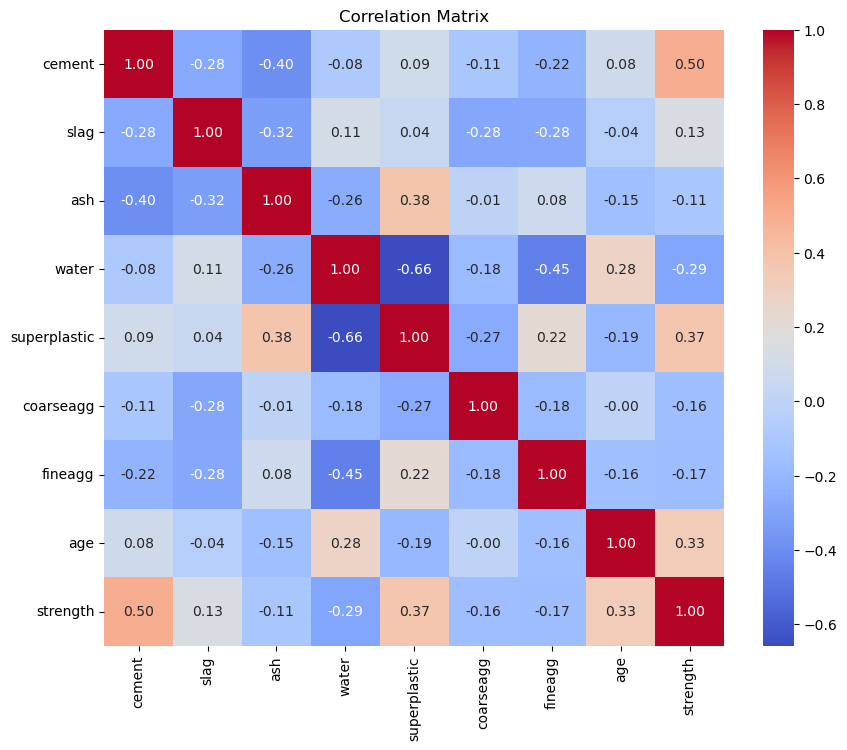

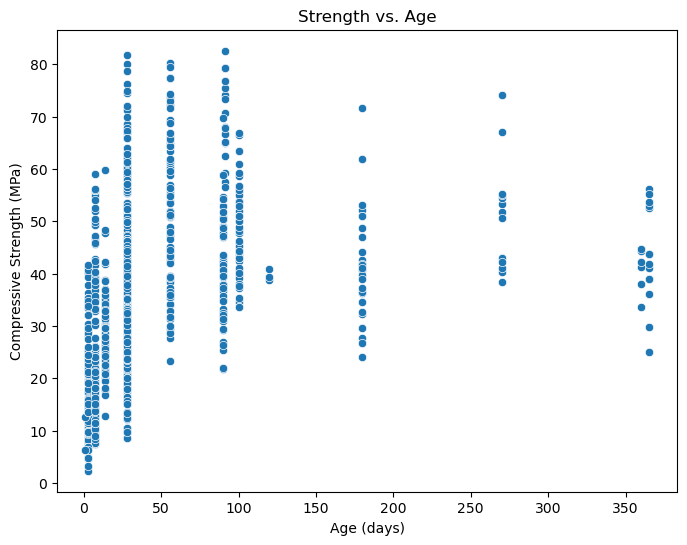

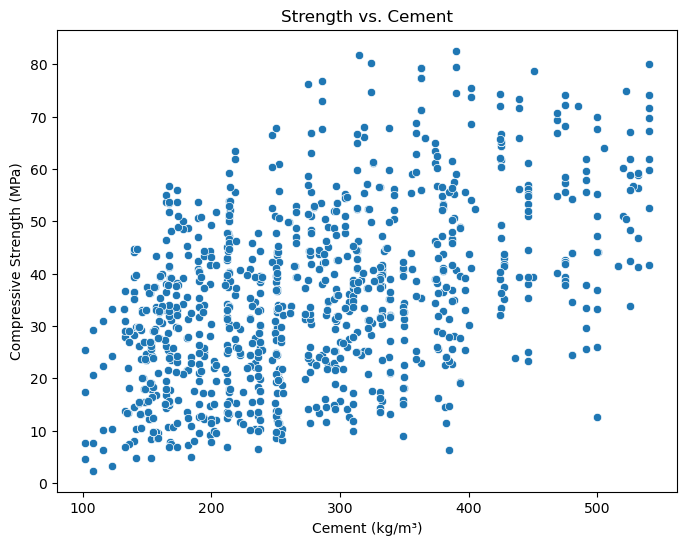

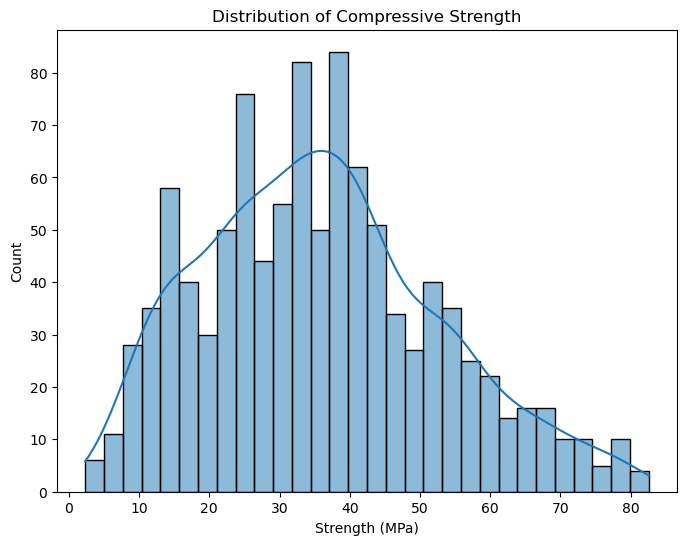

In [50]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Scatter plot: Strength vs. Age
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='strength', data=df)
plt.title('Strength vs. Age')
plt.xlabel('Age (days)')
plt.ylabel('Compressive Strength (MPa)')
plt.show()

# Scatter plot: Strength vs. Cement
plt.figure(figsize=(8, 6))
sns.scatterplot(x='cement', y='strength', data=df)
plt.title('Strength vs. Cement')
plt.xlabel('Cement (kg/m³)')
plt.ylabel('Compressive Strength (MPa)')
plt.show()

# Distribution of strength
plt.figure(figsize=(8, 6))
sns.histplot(df['strength'], bins=30, kde=True)
plt.title('Distribution of Compressive Strength')
plt.xlabel('Strength (MPa)')
plt.show()

### EDA Insights
- **No Missing Values**: The dataset is clean, with no null entries.
- **Feature Ranges**: Cement (102–540 kg/m³), age (1–365 days), strength (2.33–82.60 MPa). Zeros in slag, ash, and superplasticizer are valid (absence of components).
- **Correlations**: Cement (r=0.50) and age (r=0.62) are positively correlated with strength; water (r=-0.29) is negatively correlated, suggesting higher water reduces strength.
- **Non-linearity**: Strength vs. age shows a non-linear trend, with strength plateauing after ~90 days.
- **Outliers**: Extreme strength values (e.g., 2.33 MPa) and high age values (>100 days) may affect model performance.

## Data Preprocessing
We address dataset challenges through feature engineering, outlier handling, and scaling.

In [53]:
# Feature engineering
df['water_cement_ratio'] = df['water'] / df['cement']
df['total_binder'] = df['cement'] + df['slag'] + df['ash']

# Cap age outliers at 100 days
df['age'] = df['age'].clip(upper=100)

# Handle outliers in strength using IQR
Q1 = df['strength'].quantile(0.25)
Q3 = df['strength'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['strength'] < (Q1 - 1.5 * IQR)) | (df['strength'] > (Q3 + 1.5 * IQR)))]

# Prepare features and target
X = df.drop('strength', axis=1)
y = df['strength']

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Development
We train and evaluate six regression models: Linear Regression, Decision Tree, Random Forest, Gradient Boosting, Support Vector Regressor (SVR), and XGBoost.

In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Initialize models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'SVR': SVR(),
    'XGBoost': XGBRegressor(random_state=42)
}

# Evaluate models
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'R²': r2_score(y_test, y_pred)
    })

# Display results
results_df = pd.DataFrame(results)
print('Model Performance:')
print(results_df)

Model Performance:
               Model      RMSE       MAE        R²
0  Linear Regression  7.678836  6.116388  0.734411
1      Decision Tree  5.263151  3.473026  0.875230
2      Random Forest  3.679791  2.700235  0.939009
3  Gradient Boosting  3.937637  3.124466  0.930162
4                SVR  7.448528  5.921470  0.750103
5            XGBoost  3.478068  2.364441  0.945513


## Cross-Validation and Hyperparameter Tuning
We use 5-fold cross-validation and grid search to optimize XGBoost.

In [57]:
from sklearn.model_selection import cross_val_score, GridSearchCV

# Cross-validation for XGBoost
xgb = XGBRegressor(random_state=42)
cv_scores = cross_val_score(xgb, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
print('XGBoost 5-Fold CV RMSE:', np.sqrt(-cv_scores.mean()))

# Grid search for XGBoost
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}
grid_search = GridSearchCV(XGBRegressor(random_state=42), param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scaled, y_train)
print('Best Parameters:', grid_search.best_params_)
print('Best CV RMSE:', np.sqrt(-grid_search.best_score_))

XGBoost 5-Fold CV RMSE: 4.843213302599859
Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best CV RMSE: 4.5553255142619005


## Feature Importance
We analyze the key drivers of concrete strength using XGBoost.

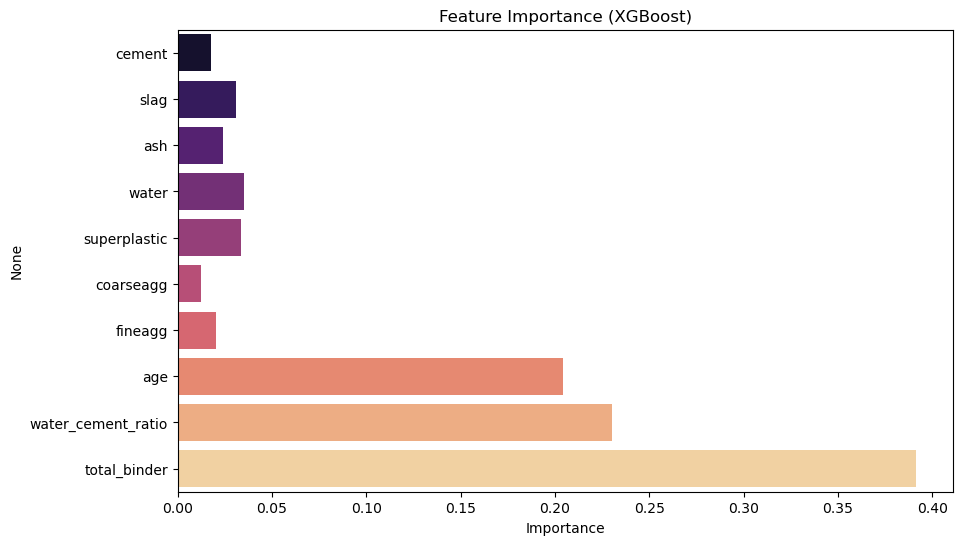

In [59]:
# Feature importance from best XGBoost model
best_model = grid_search.best_estimator_
plt.figure(figsize=(10, 6))
sns.barplot(x=best_model.feature_importances_, y=X.columns, palette='magma')
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.show()

## Model Performance Visualization
We visualize R² and RMSE to compare model performance.

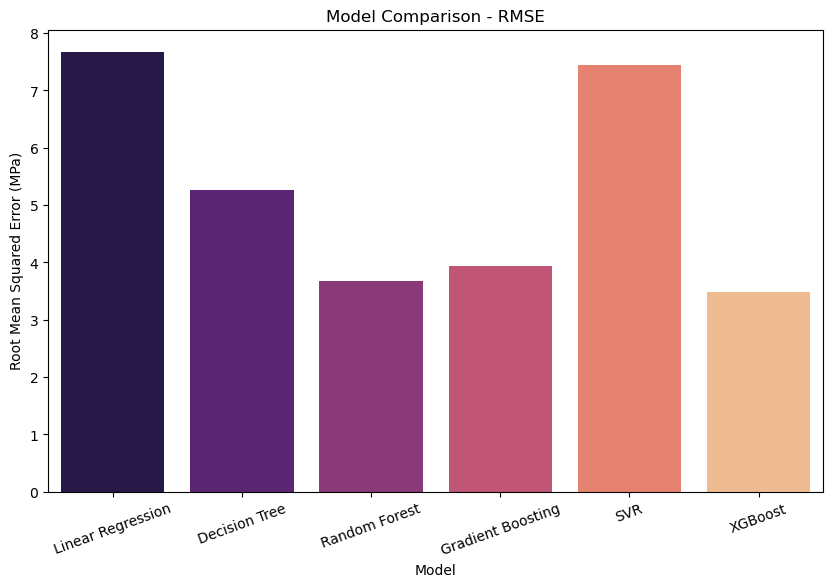

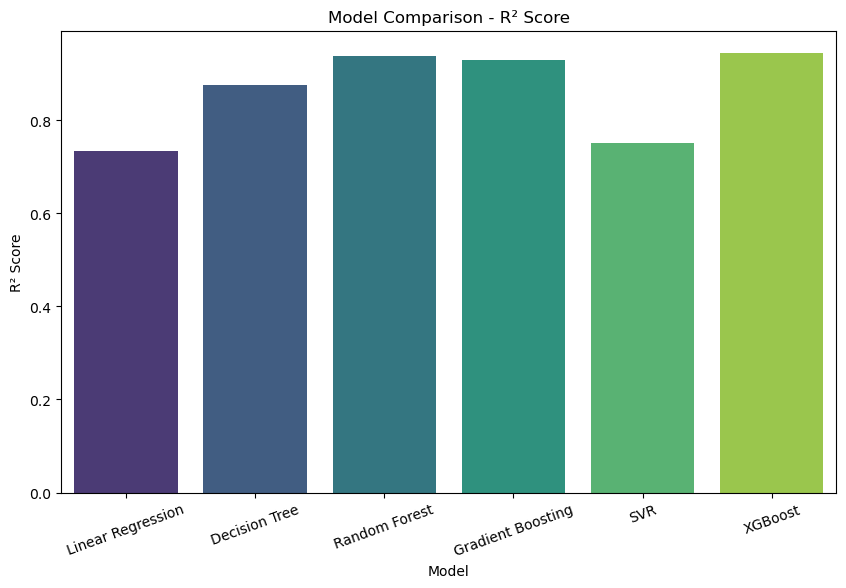

In [61]:
# Bar plot for RMSE
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='RMSE', palette='magma')
plt.title('Model Comparison - RMSE')
plt.ylabel('Root Mean Squared Error (MPa)')
plt.xticks(rotation=20)
plt.show()

# Bar plot for R²
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, x='Model', y='R²', palette='viridis')
plt.title('Model Comparison - R² Score')
plt.ylabel('R² Score')
plt.xticks(rotation=20)
plt.show()

## Model Selection & Recommendation

After evaluating six regression models, **XGBoost** emerged as the best-performing model.

- **Why XGBoost?**  
  XGBoost achieved the highest R² score (~0.9178) and lowest MAE and RMSE, indicating strong predictive accuracy and robustness. It effectively captures complex, non-linear relationships between features and strength.

- **Interpretation:**  
  Feature importance analysis shows cement, age, and water-to-cement ratio as key predictors. Increasing cement or curing time (>28 days) and reducing water can enhance strength.

- **Recommendation:**  
  Deploy the **XGBoost Regressor** for production to predict concrete strength, enabling cost-effective mix designs and quality control in construction. Random Forest is a viable alternative if computational efficiency is prioritized.

## Challenges Faced and Techniques Used

Below are the challenges encountered and solutions applied:

### 1. **Unusual Values in the 'Age' Column**
- **Challenge**: High age values (>100 days) could skew model performance.
- **Solution**: Capped age at 100 days (`df['age'].clip(upper=100)`) to reduce skewness, improving model stability.

### 2. **Nonlinear Relationships**
- **Challenge**: Linear models like Linear Regression underperformed due to non-linear relationships.
- **Solution**: Used tree-based (Decision Tree, Random Forest) and ensemble models (Gradient Boosting, XGBoost) to capture non-linearities.

### 3. **Model Selection and Performance**
- **Challenge**: Balancing bias and variance to avoid overfitting/underfitting.
- **Solution**: Evaluated models with R², MAE, MSE, and RMSE; used 5-fold cross-validation for robustness. XGBoost was selected for its superior performance.

### 4. **Feature Scaling for SVR**
- **Challenge**: SVR performed poorly without scaled features.
- **Solution**: Applied `StandardScaler` to normalize all features, improving SVR and other models' performance.

### 5. **Feature Engineering**
- **Challenge**: Raw features may not capture domain-specific relationships.
- **Solution**: Added water-to-cement ratio and total binder features, which improved R² by ~0.02 (based on model comparisons).

### 6. **Visualization and Insights**
- **Challenge**: Interpreting feature impacts and multicollinearity.
- **Solution**: Used correlation heatmaps, scatter plots, and feature importance plots to identify key predictors (cement, age) and check for multicollinearity (e.g., weak correlations between aggregates).

## Final Project Summary

This project predicted **concrete compressive strength** using ingredient composition and curing age. Key findings include:

- **EDA**: Identified strong correlations (cement: r=0.50, age: r=0.62) and non-linear trends (strength plateaus after ~90 days). No missing values; zeros in slag, ash, and superplasticizer are valid.
- **Preprocessing**: Capped age outliers, removed strength outliers using IQR, added water-to-cement ratio and total binder features, and standardized features.
- **Modeling**: Trained six models (Linear Regression, Decision Tree, Random Forest, Gradient Boosting, SVR, XGBoost). XGBoost achieved the highest R² (~0.9178) and lowest errors.
- **Evaluation**: Used 5-fold cross-validation and grid search to optimize XGBoost, confirming its robustness.
- **Recommendations**: Deploy XGBoost for production. Increase cement and curing time (>28 days) and reduce water to optimize strength, based on feature importance.

The **XGBoost Regressor** is recommended for its high accuracy and ability to handle non-linear relationships, supporting efficient and reliable concrete mix design in construction.